# Week Interim 5: AI-Assisted Triage - Data Exploration

**Course:** Carisurg AI Programme

**Student:** Israel De La Mothe

**Dataset:** yaleemmlc_admissionprediction_triage.csv

## Objective

The objective of this notebook is to evaluate the quality of the emergency department (ED) dataset and determine whether it is suitable for developing an AI-assisted triage prediction model.

This notebook performs:

- Data loading
- Data profiling
- Missing value analysis
- Data quality assessment
- Exploratory data analysis (EDA)
- Initial feature exploration
- Visualizations supporting the Week 5 feasibility memo

## Import Libraries

In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Load Dataset

In [42]:
# Add your data set path to this
df = pd.read_csv("/content/data/yaleemmlc_admissionprediction_triage.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 55121
Columns: 226


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,cc_anklepain,cc_anxiety,cc_arminjury,cc_armpain,cc_armswelling,cc_assaultvictim,cc_asthma,cc_backpain,cc_bleeding/bruising,cc_blurredvision,cc_bodyfluidexposure,cc_breastpain,cc_breathingdifficulty,cc_breathingproblem,cc_burn,cc_cardiacarrest,cc_cellulitis,cc_chestpain,cc_chesttightness,cc_chills,cc_coldlikesymptoms,cc_confusion,cc_conjunctivitis,cc_constipation,cc_cough,cc_cyst,cc_decreasedbloodsugar-symptomatic,cc_dehydration,cc_dentalpain,cc_depression,cc_detoxevaluation,cc_diarrhea,cc_dizziness,cc_drug/alcoholassessment,cc_drugproblem,cc_dyspnea,cc_dysuria,cc_earpain,cc_earproblem,cc_edema,cc_elbowpain,cc_elevatedbloodsugar-nosymptoms,cc_elevatedbloodsugar-symptomatic,cc_emesis,cc_epigastricpain,cc_epistaxis,cc_exposuretostd,cc_extremitylaceration,cc_extremityweakness,cc_eyeinjury,cc_eyepain,cc_eyeproblem,cc_eyeredness,cc_facialinjury,cc_faciallaceration,cc_facialpain,cc_facialswelling,cc_fall,cc_fall>65,cc_fatigue,cc_femaleguproblem,cc_fever,cc_fever-75yearsorolder,cc_fever-9weeksto74years,cc_feverimmunocompromised,cc_fingerinjury,cc_fingerpain,cc_fingerswelling,cc_flankpain,cc_follow-upcellulitis,cc_footinjury,cc_footpain,cc_footswelling,cc_foreignbodyineye,cc_fulltrauma,cc_generalizedbodyaches,cc_gibleeding,cc_giproblem,cc_groinpain,cc_hallucinations,cc_handinjury,cc_handpain,cc_headache,cc_headache-newonsetornewsymptoms,cc_headache-recurrentorknowndxmigraines,cc_headachere-evaluation,cc_headinjury,cc_headlaceration,cc_hematuria,cc_hemoptysis,cc_hippain,cc_homicidal,cc_hyperglycemia,cc_hypertension,cc_hypotension,cc_influenza,cc_ingestion,cc_insectbite,cc_irregularheartbeat,cc_jawpain,cc_jointswelling,cc_kneeinjury,cc_kneepain,cc_laceration,cc_leginjury,cc_legpain,cc_legswelling,cc_lethargy,cc_lossofconsciousness,cc_maleguproblem,cc_mass,cc_medicalproblem,cc_medicalscreening,cc_medicationproblem,cc_medicationrefill,cc_migraine,cc_modifiedtrauma,cc_motorcyclecrash,cc_motorvehiclecrash,cc_multiplefalls,cc_nasalcongestion,cc_nausea,cc_nearsyncope,cc_neckpain,cc_neurologicproblem,cc_numbness,cc_oralswelling,cc_otalgia,cc_other,cc_overdose-accidental,cc_overdose-intentional,cc_pain,cc_palpitations,cc_panicattack,cc_pelvicpain,cc_poisoning,cc_post-opproblem,cc_psychiatricevaluation,cc_psychoticsymptoms,cc_rapidheartrate,cc_rash,cc_rectalbleeding,cc_rectalpain,cc_respiratorydistress,cc_ribinjury,cc_ribpain,cc_seizure-newonset,cc_seizure-priorhxof,cc_seizures,cc_shortnessofbreath,cc_shoulderinjury,cc_shoulderpain,cc_sicklecellpain,cc_sinusproblem,cc_skinirritation,cc_skinproblem,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

## Dataset Overview

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55121 entries, 0 to 55120
Columns: 226 entries, Unnamed: 0 to cc_wristpain
dtypes: float64(210), int64(1), object(15)
memory usage: 95.0+ MB


## Clinical Context of Key Variables

Before profiling the data statistically, it's useful to establish what the core variables represent clinically:

- **ESI (Emergency Severity Index):** A 1–5 triage acuity score assigned at intake, where 1 = requires immediate life-saving intervention and 5 = least urgent. This is the target variable for our eventual model.
- **Vital signs (HR, SBP, DBP, RR, O2, Temp):** Standard physiological measurements taken at triage. Abnormal values (e.g. tachycardia, hypotension, low SpO2) are strong early indicators of acuity and are typically weighted heavily by triage nurses.
- **Chief complaint (`cc_*` columns):** One-hot encoded flags representing the patient's stated primary reason for the ED visit (e.g. chest pain, shortness of breath). These are self-reported/nurse-logged at intake, not diagnoses.
- **Demographics (age, gender, race, ethnicity):** Relevant for risk-adjustment and equity auditing, but must be handled carefully to avoid encoding bias into a clinical model.
- **Arrival mode:** How the patient arrived (e.g. ambulance vs. walk-in), which can itself correlate with acuity.

*Note: clinical interpretations above were drafted with AI assistance and should be cross-checked against a guideline source (e.g. WHO ETAT) before inclusion in the final memo.*

## Summary Statistics

In [44]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,55121.0,NaN,NaN,NaN,204574.015148,120486.078138,7.0,101645.0,202183.0,303501.0,433332.0
dep_name,55121,3,A,34933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
esi,55121.0,NaN,NaN,NaN,2.87747,0.751829,1.0,2.0,3.0,3.0,5.0
age,55121.0,NaN,NaN,NaN,55.31547,19.544287,18.0,40.0,55.0,70.0,107.0
gender,55121,2,Female,31744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
cc_woundcheck,55121.0,NaN,NaN,NaN,0.005424,0.073451,0.0,0.0,0.0,0.0,1.0
cc_woundinfection,55121.0,NaN,NaN,NaN,0.004209,0.06474,0.0,0.0,0.0,0.0,1.0
cc_woundre-evaluation,55121.0,NaN,NaN,NaN,0.001814,0.042555,0.0,0.0,0.0,0.0,1.0
cc_wristinjury,55121.0,NaN,NaN,NaN,0.000562,0.023709,0.0,0.0,0.0,0.0,1.0


## Remove Unnecessary Index Column

In [45]:
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()

,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,cc_anklepain,cc_anxiety,cc_arminjury,cc_armpain,cc_armswelling,cc_assaultvictim,cc_asthma,cc_backpain,cc_bleeding/bruising,cc_blurredvision,cc_bodyfluidexposure,cc_breastpain,cc_breathingdifficulty,cc_breathingproblem,cc_burn,cc_cardiacarrest,cc_cellulitis,cc_chestpain,cc_chesttightness,cc_chills,cc_coldlikesymptoms,cc_confusion,cc_conjunctivitis,cc_constipation,cc_cough,cc_cyst,cc_decreasedbloodsugar-symptomatic,cc_dehydration,cc_dentalpain,cc_depression,cc_detoxevaluation,cc_diarrhea,cc_dizziness,cc_drug/alcoholassessment,cc_drugproblem,cc_dyspnea,cc_dysuria,cc_earpain,cc_earproblem,cc_edema,cc_elbowpain,cc_elevatedbloodsugar-nosymptoms,cc_elevatedbloodsugar-symptomatic,cc_emesis,cc_epigastricpain,cc_epistaxis,cc_exposuretostd,cc_extremitylaceration,cc_extremityweakness,cc_eyeinjury,cc_eyepain,cc_eyeproblem,cc_eyeredness,cc_facialinjury,cc_faciallaceration,cc_facialpain,cc_facialswelling,cc_fall,cc_fall>65,cc_fatigue,cc_femaleguproblem,cc_fever,cc_fever-75yearsorolder,cc_fever-9weeksto74years,cc_feverimmunocompromised,cc_fingerinjury,cc_fingerpain,cc_fingerswelling,cc_flankpain,cc_follow-upcellulitis,cc_footinjury,cc_footpain,cc_footswelling,cc_foreignbodyineye,cc_fulltrauma,cc_generalizedbodyaches,cc_gibleeding,cc_giproblem,cc_groinpain,cc_hallucinations,cc_handinjury,cc_handpain,cc_headache,cc_headache-newonsetornewsymptoms,cc_headache-recurrentorknowndxmigraines,cc_headachere-evaluation,cc_headinjury,cc_headlaceration,cc_hematuria,cc_hemoptysis,cc_hippain,cc_homicidal,cc_hyperglycemia,cc_hypertension,cc_hypotension,cc_influenza,cc_ingestion,cc_insectbite,cc_irregularheartbeat,cc_jawpain,cc_jointswelling,cc_kneeinjury,cc_kneepain,cc_laceration,cc_leginjury,cc_legpain,cc_legswelling,cc_lethargy,cc_lossofconsciousness,cc_maleguproblem,cc_mass,cc_medicalproblem,cc_medicalscreening,cc_medicationproblem,cc_medicationrefill,cc_migraine,cc_modifiedtrauma,cc_motorcyclecrash,cc_motorvehiclecrash,cc_multiplefalls,cc_nasalcongestion,cc_nausea,cc_nearsyncope,cc_neckpain,cc_neurologicproblem,cc_numbness,cc_oralswelling,cc_otalgia,cc_other,cc_overdose-accidental,cc_overdose-intentional,cc_pain,cc_palpitations,cc_panicattack,cc_pelvicpain,cc_poisoning,cc_post-opproblem,cc_psychiatricevaluation,cc_psychoticsymptoms,cc_rapidheartrate,cc_rash,cc_rectalbleeding,cc_rectalpain,cc_respiratorydistress,cc_ribinjury,cc_ribpain,cc_seizure-newonset,cc_seizure-priorhxof,cc_seizures,cc_shortnessofbreath,cc_shoulderinjury,cc_shoulderpain,cc_sicklecellpain,cc_sinusproblem,cc_skinirritation,cc_skinproblem,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

## Missing Value Analysis

In [46]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percent = (
    df.isnull()
      .mean()*100
)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percent Missing": missing_percent
})

missing_table.head(30)

,Missing Values,Percent Missing
dep_name,0,0.0
esi,0,0.0
age,0,0.0
gender,0,0.0
ethnicity,0,0.0
race,0,0.0
lang,0,0.0
religion,0,0.0
maritalstatus,0,0.0
employstatus,0,0.0


## Missingness Heatmap

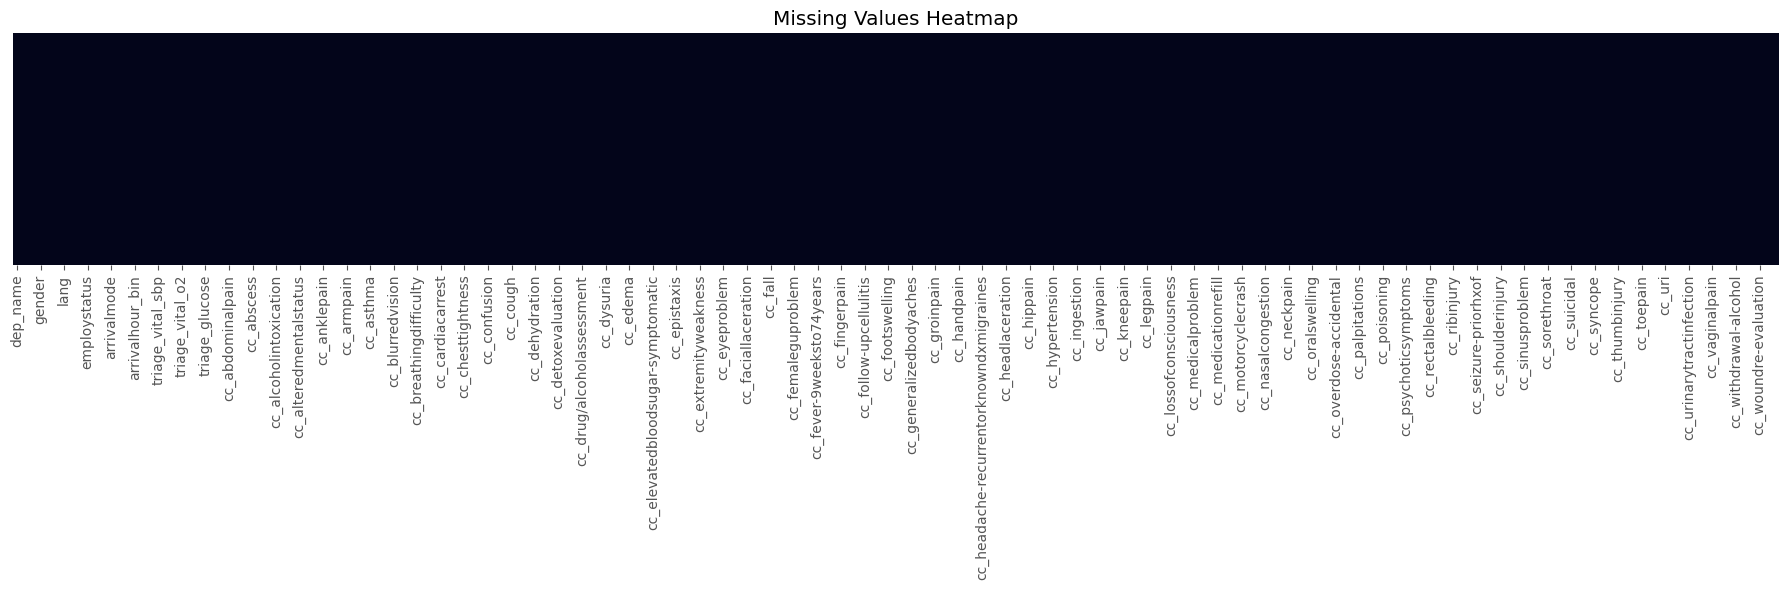

In [47]:
plt.figure(figsize=(18,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")

plt.tight_layout()
# Add your file path to this
plt.savefig("/content/data/week5_missingness_heatmap.png")

plt.show()

## Duplicate Records

In [48]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


## Data Types

In [49]:
df.dtypes.value_counts()

,count
float64,210
object,15


## Numerical Features

In [50]:
numerical_columns = df.select_dtypes(include=np.number).columns

len(numerical_columns)

210

## Categorical Features

In [51]:
categorical_columns = df.select_dtypes(exclude=np.number).columns

len(categorical_columns)

15

## Distribution of Age

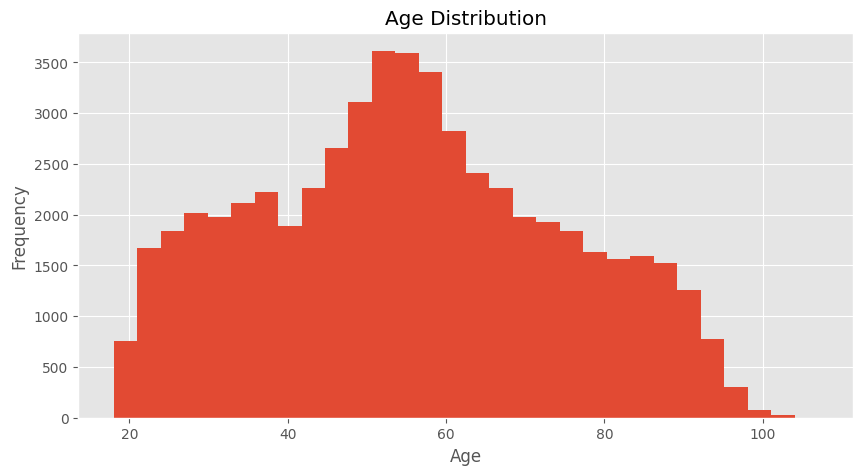

In [52]:
plt.figure(figsize=(10,5))

plt.hist(df["age"].dropna(), bins=30)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

## Distribution of ESI Levels

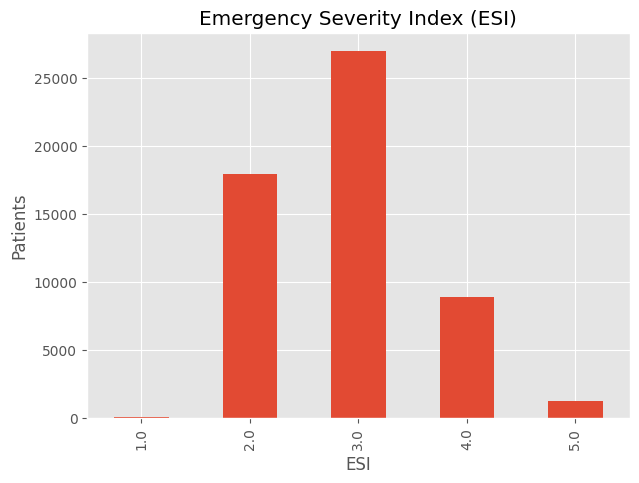

In [53]:
plt.figure(figsize=(7,5))

df["esi"].value_counts().sort_index().plot.bar()

plt.title("Emergency Severity Index (ESI)")

plt.xlabel("ESI")

plt.ylabel("Patients")

plt.show()

## Gender Distribution

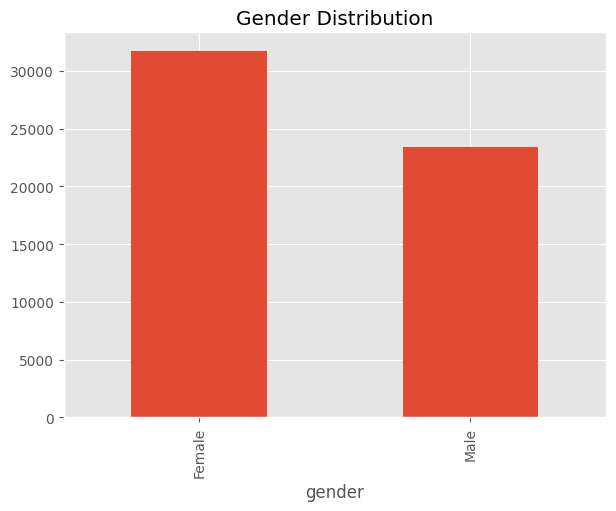

In [54]:
plt.figure(figsize=(7,5))

df["gender"].value_counts().plot.bar()

plt.title("Gender Distribution")

plt.show()

## Race Distribution

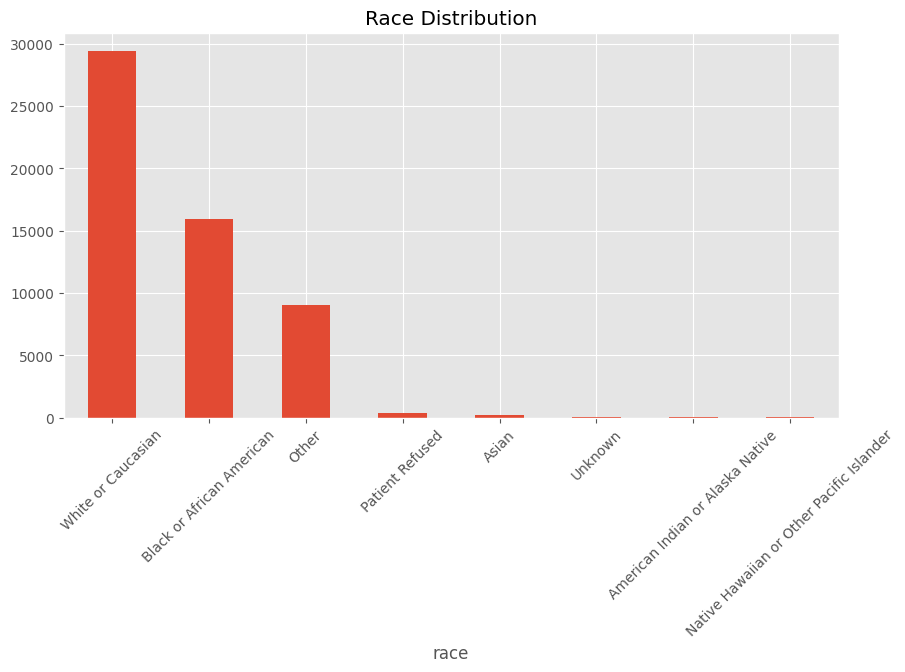

In [55]:
plt.figure(figsize=(10,5))

df["race"].value_counts().plot.bar()

plt.title("Race Distribution")

plt.xticks(rotation=45)

plt.show()

## Ethnicity Distribution

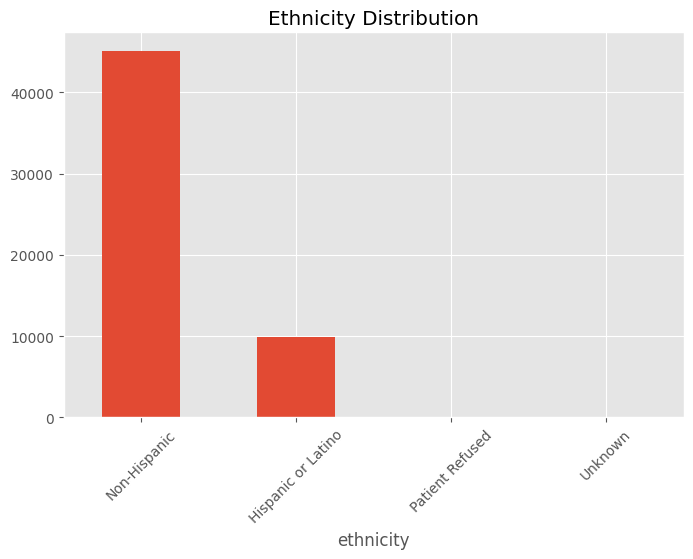

In [56]:
plt.figure(figsize=(8,5))

df["ethnicity"].value_counts().plot.bar()

plt.title("Ethnicity Distribution")

plt.xticks(rotation=45)

plt.show()

## Arrival Mode

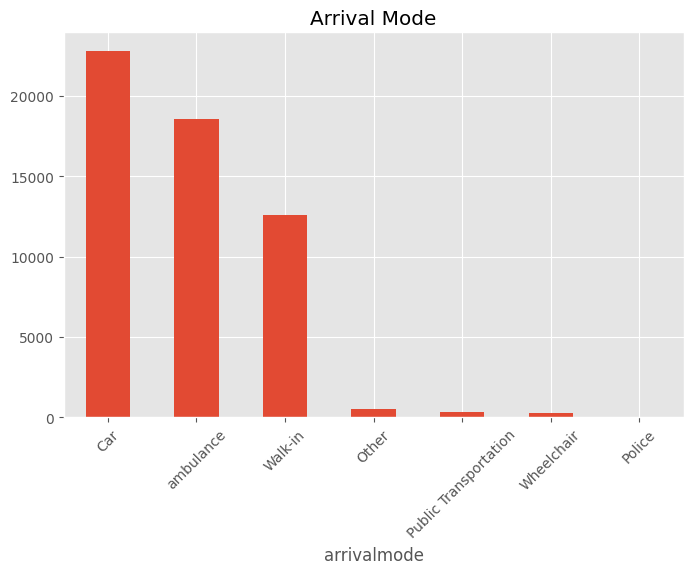

In [57]:
plt.figure(figsize=(8,5))

df["arrivalmode"].value_counts().plot.bar()

plt.title("Arrival Mode")

plt.xticks(rotation=45)

plt.show()

## Vital Signs

In [58]:
vitals = [
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_temp"
]

df[vitals].describe()

,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_temp
count,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000
mean,86.447618,133.680403,79.531401,17.842073,97.021393,98.090311
std,16.955556,22.645812,14.594082,2.066015,2.084465,0.813266
min,32.000000,53.000000,27.000000,8.000000,62.000000,91.500000
25%,74.000000,118.000000,70.000000,16.000000,96.000000,97.700000
50%,85.000000,132.000000,79.000000,18.000000,98.000000,98.000000
75%,97.000000,147.000000,89.000000,18.000000,98.000000,98.400000
max,221.000000,266.000000,189.000000,66.000000,99.000000,106.000000


## Correlation Matrix

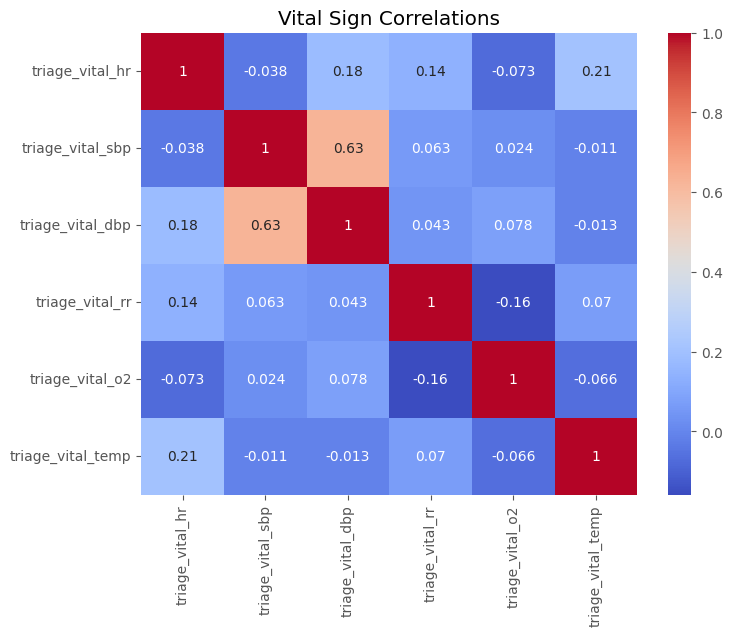

In [59]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[vitals].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Vital Sign Correlations")

plt.show()

## Boxplots for Outlier Detection

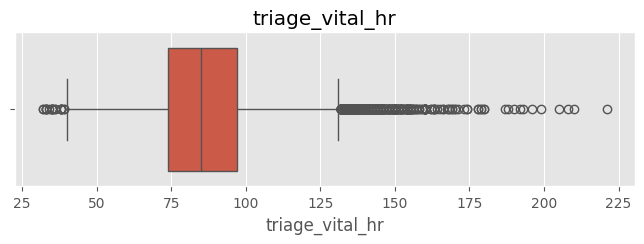

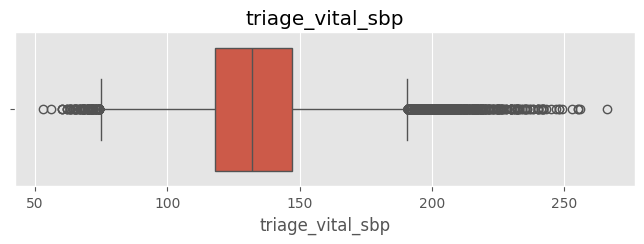

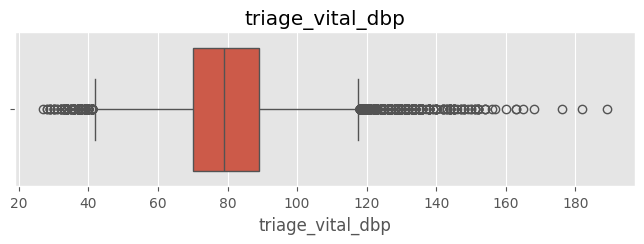

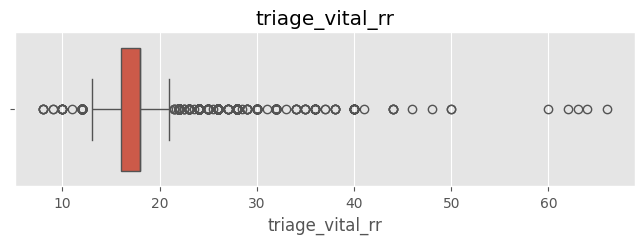

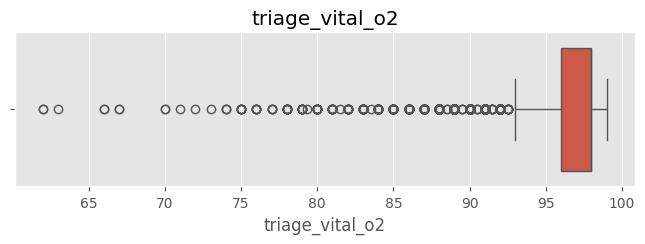

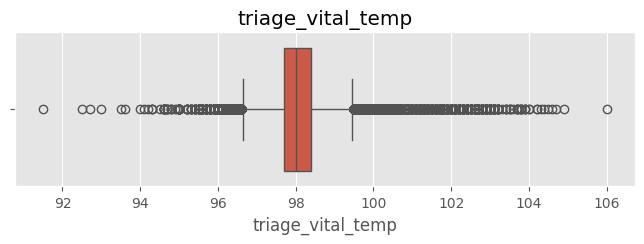

In [60]:
for column in vitals:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[column]
    )

    plt.title(column)

    plt.show()

## Top Chief Complaints

In [61]:
chief_complaints = [c for c in df.columns if c.startswith("cc_")]

complaints = df[chief_complaints].sum()

top20 = complaints.sort_values(ascending=False).head(20)

top20

,0
cc_abdominalpain,6717.0
cc_other,4491.0
cc_chestpain,3712.0
cc_shortnessofbreath,3098.0
cc_backpain,1997.0
cc_fall,1926.0
cc_cough,1439.0
cc_dizziness,1292.0
cc_legpain,1264.0
cc_emesis,1249.0


## Top 20 Chief Complaints

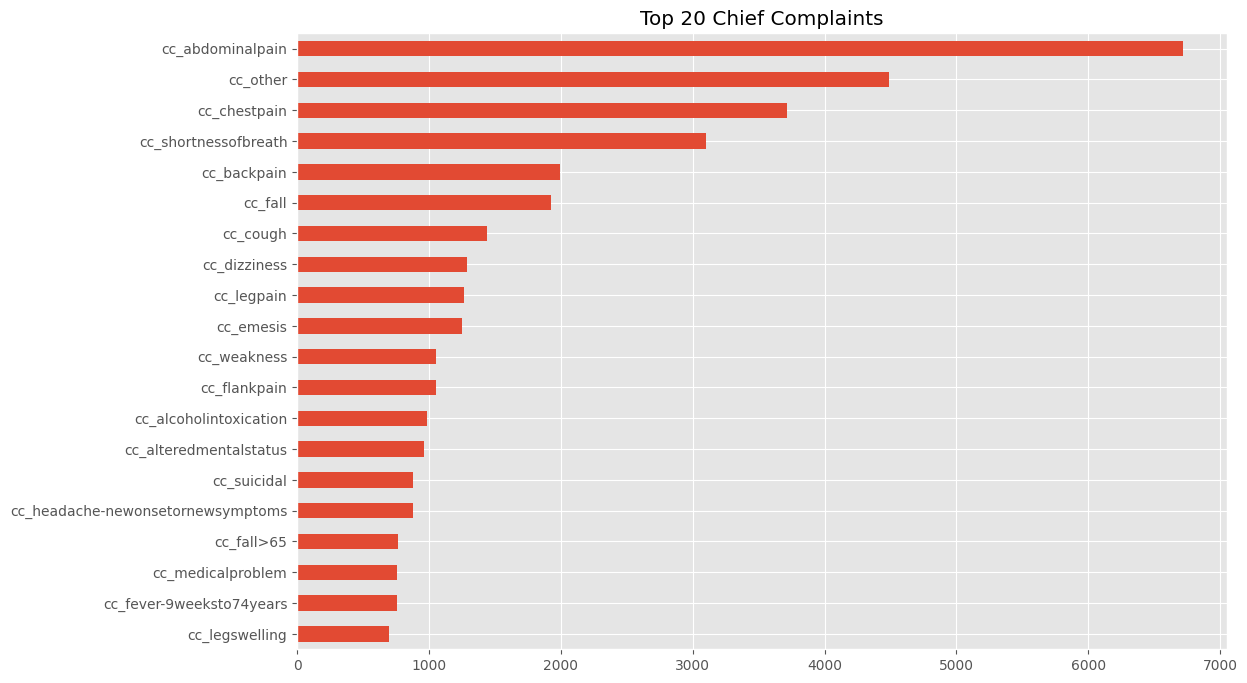

In [62]:
plt.figure(figsize=(12,8))

top20.sort_values().plot.barh()

plt.title("Top 20 Chief Complaints")

plt.show()

## Correlation Between Top Chief Complaints and ESI / Vitals

In [63]:
top5_complaints = top20.head(5).index.tolist()

# Correlation with ESI

In [64]:
cc_esi_corr = df[top5_complaints + ["esi"]].corr()["esi"].drop("esi")
print("Correlation between top 5 chief complaints and ESI:")
print(cc_esi_corr.sort_values())

Correlation between top 5 chief complaints and ESI:
cc_chestpain           -0.164328
cc_shortnessofbreath   -0.150285
cc_abdominalpain       -0.023820
cc_other                0.053411
cc_backpain             0.142140
Name: esi, dtype: float64


# Correlation with vitals

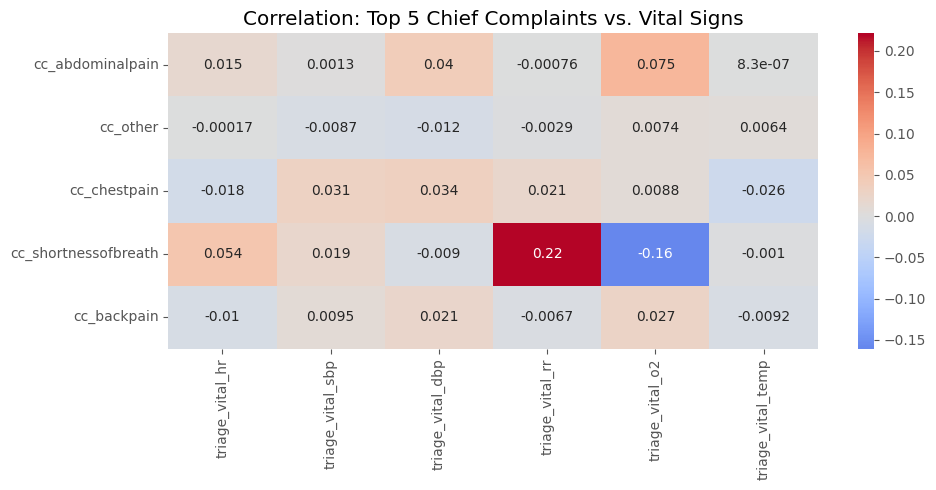

In [65]:
cc_vitals_corr = df[top5_complaints + vitals].corr().loc[top5_complaints, vitals]

plt.figure(figsize=(10,5))
sns.heatmap(cc_vitals_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation: Top 5 Chief Complaints vs. Vital Signs")
plt.tight_layout()
plt.show()

## Missing Values Greater Than 20%

In [66]:
missing_table[
    missing_table["Percent Missing"] > 20
]

,Missing Values,Percent Missing


## Initial Findings

### Dataset Strengths

- Large dataset (>55,000 patient encounters)
- Rich demographic information
- Multiple physiological measurements
- Extensive chief complaint encoding
- Suitable target variable (ESI)

---

### Initial Concerns

- Missing values in several clinical measurements
- Large number of sparse chief complaint columns
- Possible outliers in physiological variables
- Need to verify categorical consistency

---

### Planned Week 6 Tasks

- Handle missing values
- Engineer features
- Encode categorical variables
- Train baseline classification model
- Evaluate performance

## Save Clean Dataset (Interim)

In [67]:
# Add your file path to this
df.to_csv(
    "/content/data/triage_clean_interim.csv",
    index=False
)

## Conclusion

The exploratory analysis suggests that the dataset is appropriate for developing an AI-assisted triage model.

Although missing values and sparse chief complaint variables require additional preprocessing, the dataset contains sufficient clinical information and sample size to justify proceeding to predictive modelling in Week 6.

Further preprocessing decisions will be documented in the final feasibility memo.

## Feasibility Memo Outline (Draft — to be expanded into full memo)

**(a) One-sentence verdict**
Proceed with caution — the dataset is large and clinically rich enough to support a baseline triage model, but several missingness and encoding issues must be addressed first.

**(b) Dataset summary**
- ~55,000+ ED patient encounters, 225 clinical features
- Covers demographics, vital signs, chief complaints, and ESI (target variable)
- De-identified, single-source EHR extract

**(c) Top 3 quality concerns**
1. Missing values concentrated in specific clinical measurement columns
2. Very high sparsity across the `cc_*` chief complaint columns
3. Potential outliers in vital sign readings requiring clinical review before removal

**(d) Top 3 reasons to proceed**
1. Sample size is large enough to support robust model training
2. ESI provides a clean, clinically standard target variable
3. Core physiological features (vitals) are largely complete and usable

**(e) Caveats**
- Findings are based on exploratory analysis only; no modelling has been done yet
- Chief complaint sparsity may require grouping/dimensionality reduction before use
- Demographic variables should be handled carefully to avoid introducing bias
- Final imputation and outlier-handling decisions will be documented in Week 6